In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

df = pd.read_csv("/Users/aniketsawant/FraudDetection/fraud-detection-algorithm/data/raw/creditcard.csv")

print(df.shape)
print(df.columns)
print(df.head())
print(df.describe())
print(df.isna().sum())
pd.reset_option('all')

(284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.16717

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_61205/1473987576.py:14: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_61205/1473987576.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


I think class column represents whether this record is fraudulent or not, there are 284315 records of 0 and only 492 records of 1. I think 1 represnts fradulent transaction. This highly imbalanced data is being represented by class column. If there were more fradulent transactions that mean would have shifted more towards 1 than 0

The distribution of amount is skewed towards 0 that means there are a lot of day to day transactions happening on the credit card, while there are few high value transactions happening but these are quite rare.

The time indicates that this data is for total 2 days, it represents the time elapsed in seconds since the very first transaction in the dataset.

Having null values in the data would affect in modelling the relationship between the attribute with null values and the output variable. If any important column has null values then we might have impute or interpolate or even drop the column which might result in losing valuable information

In [15]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [47]:
df['Amount'].loc[df['Amount']>=100].value_counts()

Amount
100.00    877
150.00    497
200.00    478
144.00    414
158.00    377
         ... 
252.98      1
196.62      1
147.12      1
940.00      1
337.54      1
Name: count, Length: 23149, dtype: int64

In [53]:
df['Time'].value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
127750.0     1
62260.0      1
62259.0      1
127753.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_61205/2216686092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


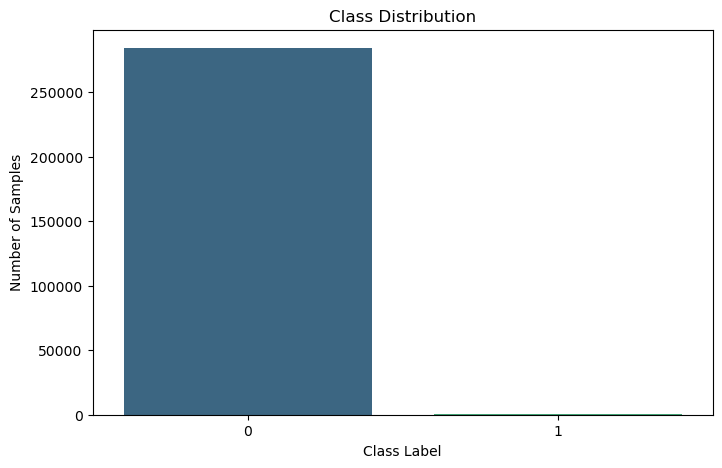

In [85]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')

path = os.path.join("outputs", "Class distribution.png")
plt.savefig(path, dpi=300)

So there are total 284315 0s and 492 1s, that means the probability of any transaction being fraudulent is 0.17%, this data is highly skewed. For a model to accurately predict any outcome it needs to be trained on unbiased data and since there is so much bias towards non-fraudulent transactions in this data our model would not be trained properly and depending upon accuracy for model performance would be a waste of time.

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_61205/2463429383.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Amount', data=frd_df, bins=5,palette='viridis')


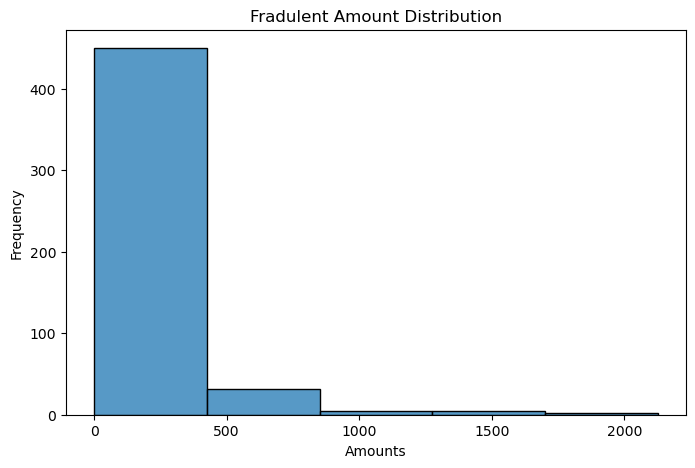

In [108]:
frd_df = df.loc[df['Class']==1]

plt.figure(figsize = (8,5))
sns.histplot(x='Amount', data=frd_df, bins=5,palette='viridis')
plt.title('Fraudulent Amount Distribution')
plt.xlabel('Amounts')
plt.ylabel('Frequency')

path = os.path.join("outputs", "Fraudulent transactions amount distribution.png")
plt.savefig(path, dpi=300)

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_61205/1752611774.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Amount', data=leg_df, bins=100,palette='viridis')


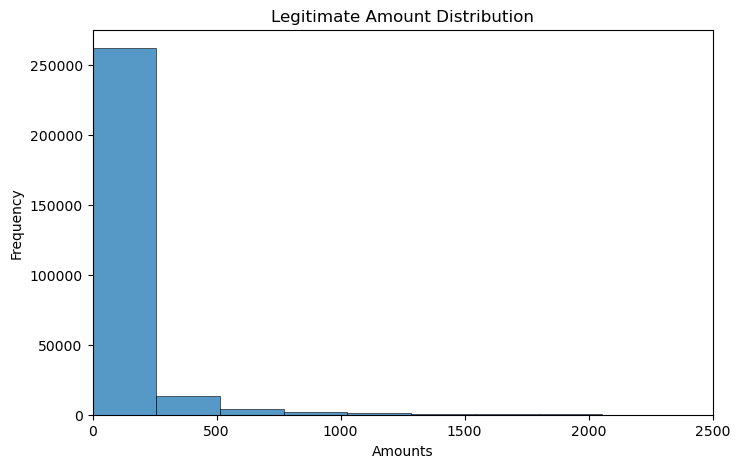

In [126]:
leg_df = df.loc[df['Class']==0]

plt.figure(figsize = (8,5))
sns.histplot(x='Amount', data=leg_df, bins=100,palette='viridis')
plt.xlim(0, 2500) 
plt.title('Legitimate Amount Distribution')
plt.xlabel('Amounts')
plt.ylabel('Frequency')

path = os.path.join("outputs", "Legitimate transactions amount distribution.png")
plt.savefig(path, dpi=300)

A lot of fradulent transactions happened between the amount of 0 to 500 that means people are using these stolen cards for everyday transactions rather than one big transaction so they would not get noticed. In case of legitimate transactions as we have observed earlier people are using these cards for their day to day transactions.